# Trabalho Prático IA - Etapa 1 (AED)

Este notebook cobre a **Etapa 1: Análise Exploratória de Dados (AED)** do trabalho de Classificação Multiclasse com MLP no Dry Bean Dataset.

Objetivos desta etapa:
- Inspecionar e limpar os dados.
- Entender distribuição e assimetria das features.
- Avaliar correlações e possíveis redundâncias.
- Analisar separação visual entre classes.
- Definir uma seleção preliminar de features para a Etapa 2.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

DATA_PATH = Path('Dry_Bean_Dataset - Dry_Beans_Dataset.csv')
print('Arquivo:', DATA_PATH.resolve())

Arquivo: /home/henriqzimer/projetos/univali/ia/trabalho-m1/Dry_Bean_Dataset - Dry_Beans_Dataset.csv


## 1) Carregamento robusto do CSV e padronização de colunas

O arquivo possui várias colunas numéricas com **vírgula decimal**. Vamos converter tudo para formato numérico (`float`) com segurança.

In [2]:
# Leitura simples do CSV
df = pd.read_csv(DATA_PATH)

# Padroniza nome da coluna
if 'roundness' in df.columns:
    df = df.rename(columns={'roundness': 'Roundness'})

# Lista de colunas numericas
num_cols = [c for c in df.columns if c != 'Class']

# Converte virgula decimal para ponto e transforma em numero
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('"', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes)

Shape: (13611, 17)

Tipos:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


## 2) Inspeção inicial do dataset

Dimensão, amostras iniciais, tipos, ausentes e distribuição de classes.

Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Valores ausentes por coluna:


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


Contagem por classe:


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

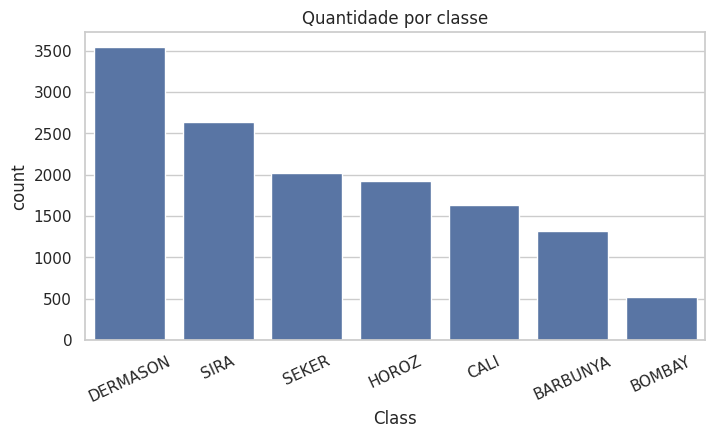

In [17]:
print('Shape:', df.shape)
display(df.head())

print('\nValores ausentes por coluna:')
display(df.isnull().sum())

print('\nContagem por classe:')
class_counts = df['Class'].value_counts()
display(class_counts)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Class', order=class_counts.index)
plt.xticks(rotation=25)
plt.title('Quantidade por classe')
plt.show()

## 3) Verificação e remoção de registros duplicados

In [3]:
n_dup = df.duplicated().sum()
print('Duplicatas encontradas:', n_dup)

shape_antes = df.shape
df = df.drop_duplicates().reset_index(drop=True)
shape_depois = df.shape

print('Shape antes:', shape_antes)
print('Shape depois:', shape_depois)

Duplicatas encontradas: 68
Shape antes: (13611, 17)
Shape depois: (13543, 17)


## 4) Distribuição das features e análise de assimetria (skewness)

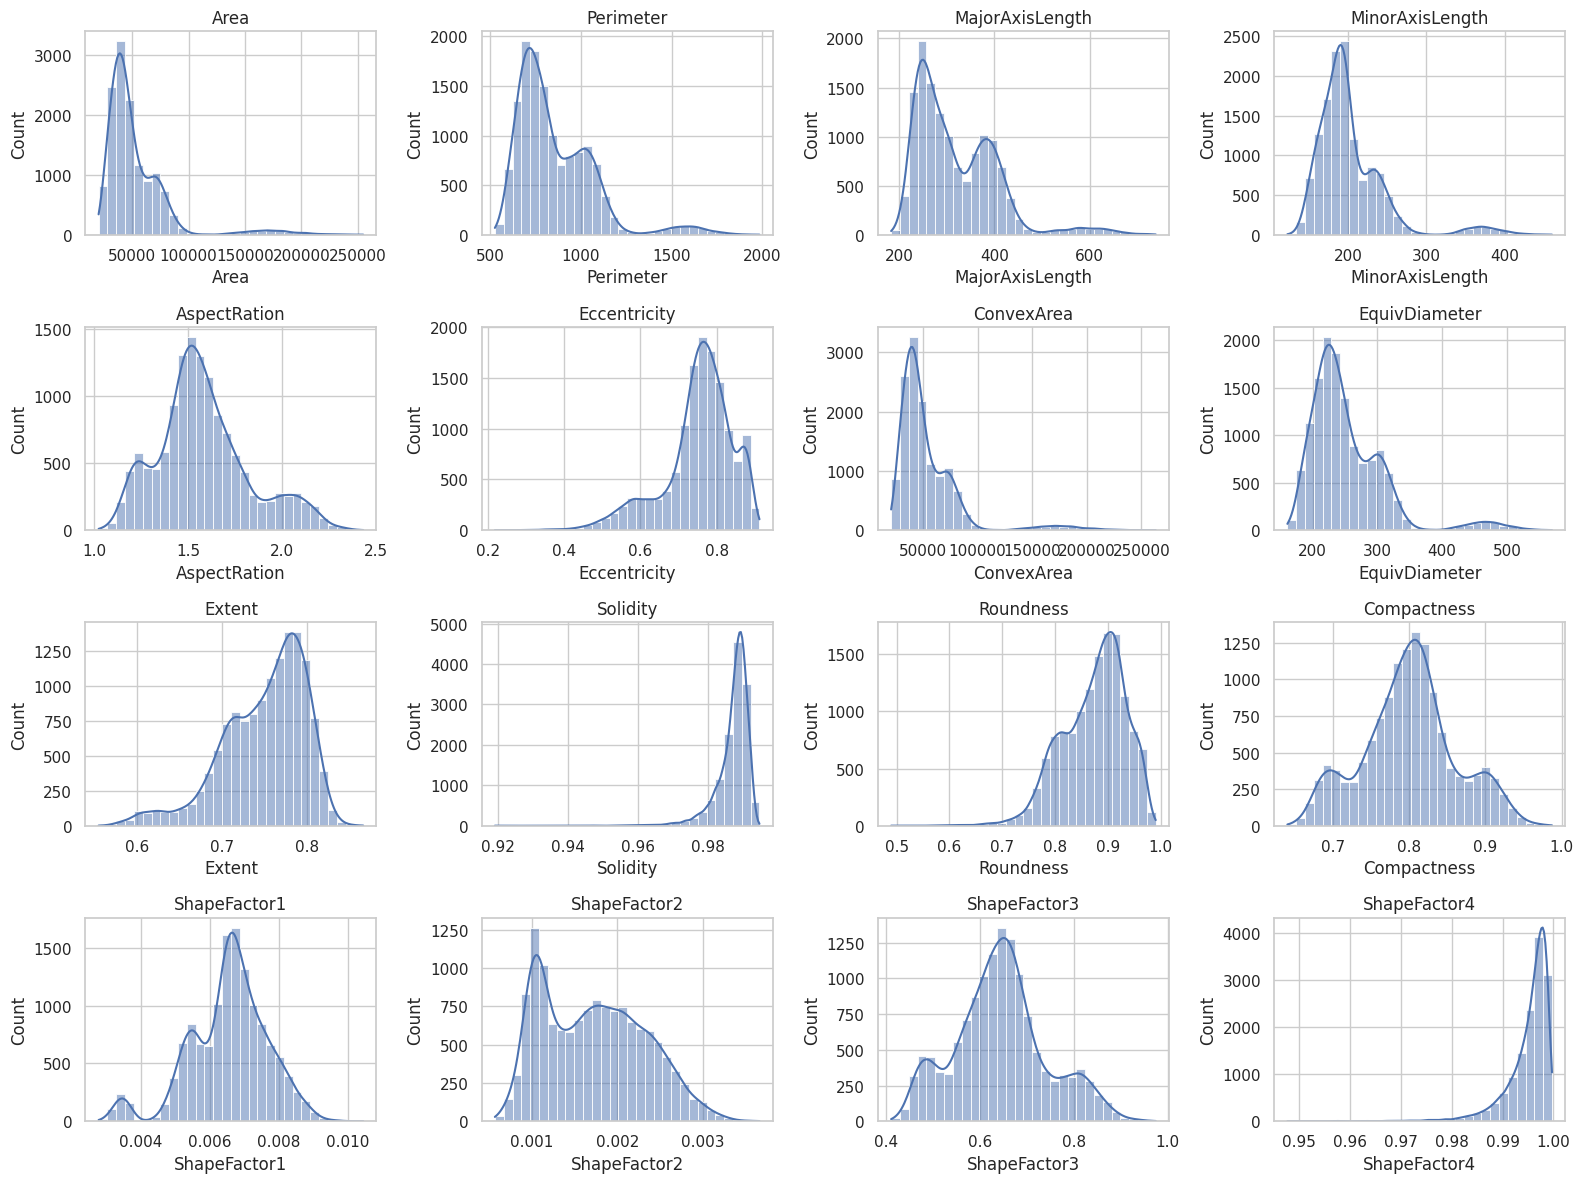

Area               2.947136
ConvexArea         2.936102
ShapeFactor4      -2.760125
Solidity          -2.546877
MinorAxisLength    2.232013
EquivDiameter      1.947303
Perimeter          1.628018
MajorAxisLength    1.365813
Eccentricity      -1.064932
Extent            -0.895655
Roundness         -0.648725
AspectRation       0.589045
ShapeFactor1      -0.530427
ShapeFactor2       0.294332
ShapeFactor3       0.242767
Compactness        0.036309
dtype: float64

Candidatas para log1p: ['Area', 'ConvexArea', 'ShapeFactor4', 'Solidity', 'MinorAxisLength', 'EquivDiameter', 'Perimeter', 'MajorAxisLength', 'Eccentricity']


In [4]:
# Histogramas das features
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Assimetria (skewness)
skew = df[num_cols].skew().sort_values(key=np.abs, ascending=False)
display(skew)

# Regra simples para log
log_candidates = skew[skew.abs() > 1].index.tolist()
print('Candidatas para log1p:', log_candidates)

## 5) Transformação logarítmica seletiva com np.log1p

Quantidade de features com log1p: 9


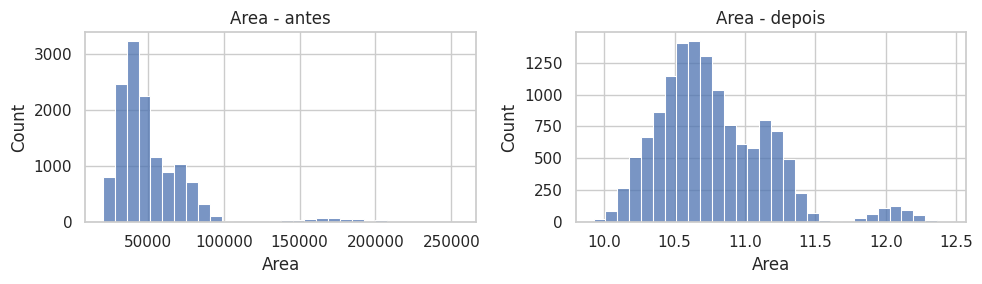

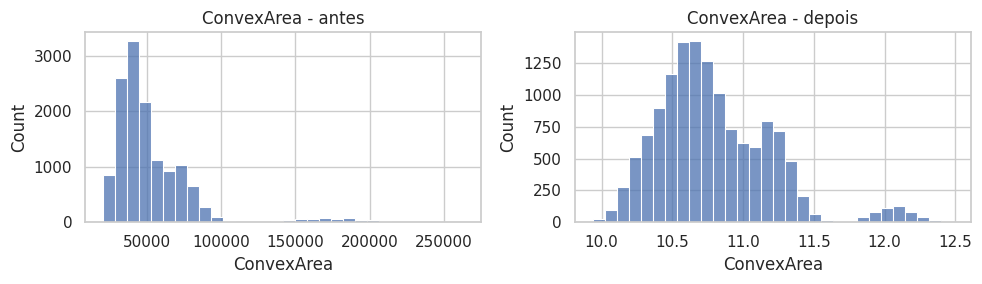

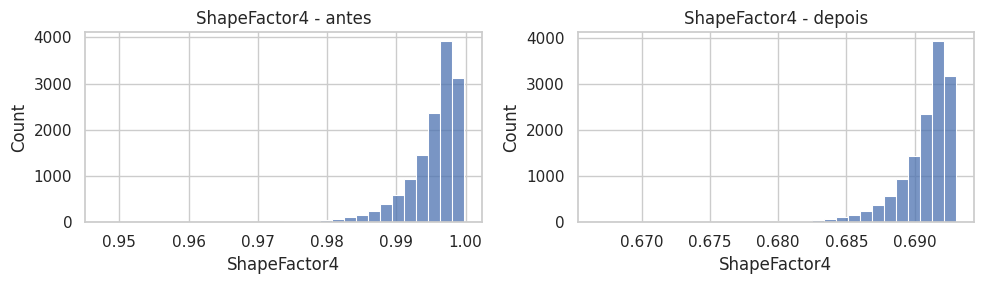

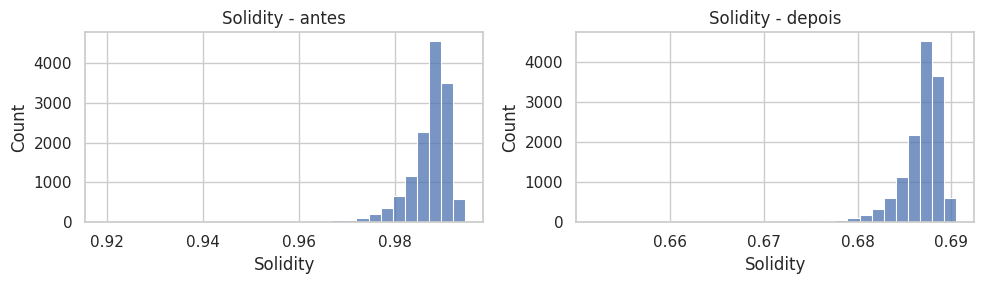

In [5]:
df_log = df.copy()

for col in log_candidates:
    df_log[col] = np.log1p(df_log[col])

print('Quantidade de features com log1p:', len(log_candidates))

# Mostra antes/depois para as 4 primeiras candidatas
for col in log_candidates[:4]:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col], bins=30, ax=ax[0])
    ax[0].set_title(f'{col} - antes')

    sns.histplot(df_log[col], bins=30, ax=ax[1])
    ax[1].set_title(f'{col} - depois')
    plt.tight_layout()
    plt.show()

## 6) Correlação de Pearson e multicolinearidade

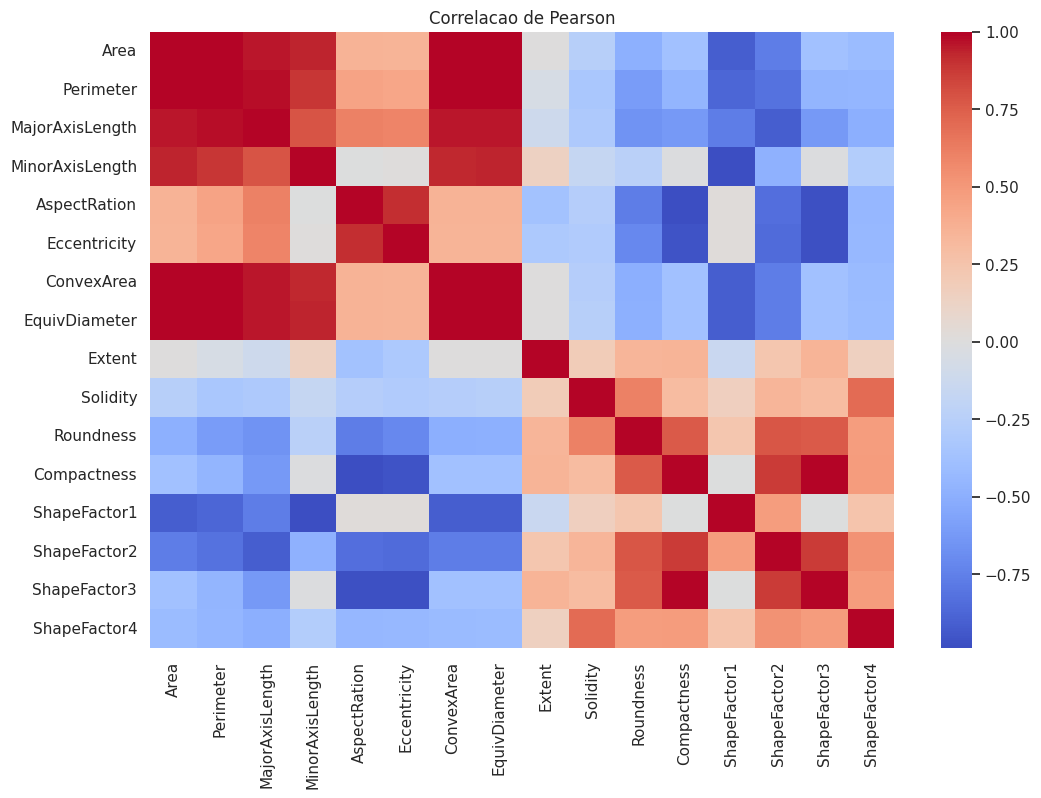

,feature_1,feature_2,corr
7,Area,EquivDiameter,1.000000
6,Area,ConvexArea,0.999938
103,ConvexArea,EquivDiameter,0.999938
190,Compactness,ShapeFactor3,0.998684
22,Perimeter,ConvexArea,0.991541
1,Area,Perimeter,0.990734
23,Perimeter,EquivDiameter,0.990709
75,AspectRation,Compactness,-0.987644
60,MinorAxisLength,ShapeFactor1,-0.987286
78,AspectRation,ShapeFactor3,-0.978528


In [21]:
corr = df_log[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlacao de Pearson')
plt.show()

# Pega pares com correlacao forte (|corr| > 0.90)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = upper.stack().reset_index()
strong_pairs.columns = ['feature_1', 'feature_2', 'corr']
strong_pairs = strong_pairs[strong_pairs['corr'].abs() > 0.90]
strong_pairs = strong_pairs.sort_values('corr', key=np.abs, ascending=False)

display(strong_pairs.head(10))

## 7) Boxplots por classe para features representativas

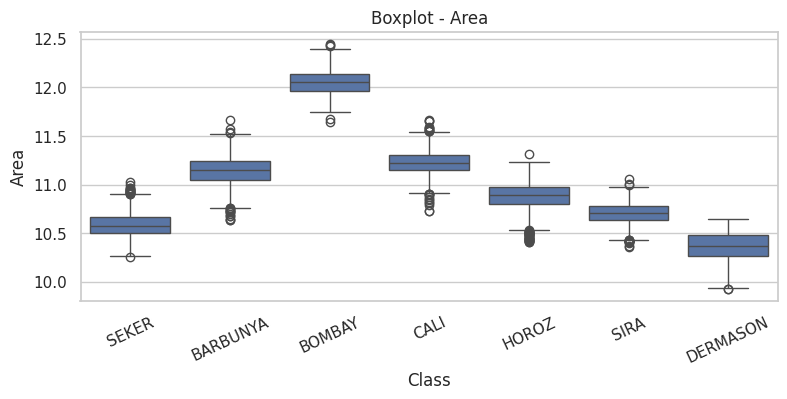

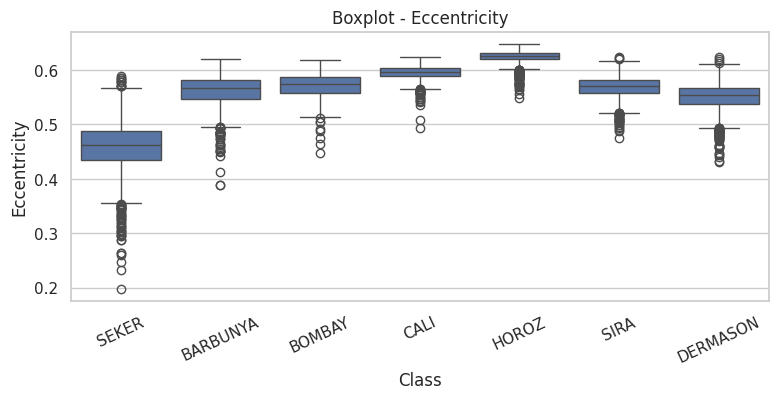

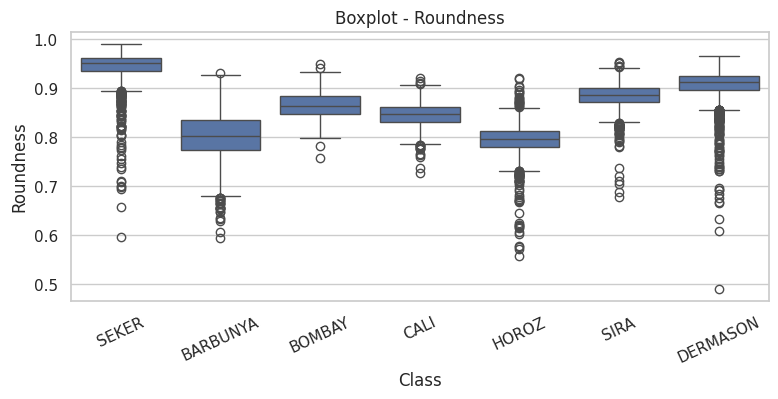

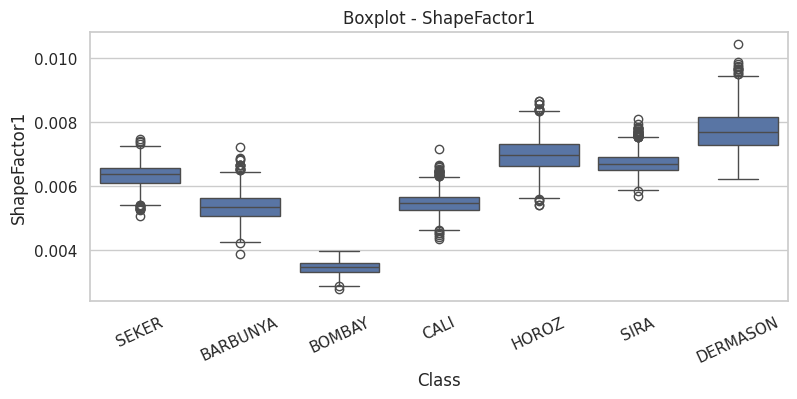

In [22]:
boxplot_features = ['Area', 'Eccentricity', 'Roundness', 'ShapeFactor1']

for feat in boxplot_features:
    plt.figure(figsize=(9, 3.5))
    sns.boxplot(data=df_log, x='Class', y=feat)
    plt.xticks(rotation=25)
    plt.title(f'Boxplot - {feat}')
    plt.show()

## 8) Seleção preliminar de features para a Etapa 2

Heurística usada:
- Manter features com boa interpretabilidade visual (boxplots).
- Evitar redundância extrema entre pares muito correlacionados.
- Considerar features após transformação log quando aplicável.

In [6]:
# Selecao simples de features para a Etapa 2
selected_features = [
    'Area', 'MinorAxisLength', 'Eccentricity', 'Extent',
    'Solidity', 'Roundness', 'ShapeFactor1', 'ShapeFactor3'
]

print('Features escolhidas:')
print(selected_features)

# Salva para reaproveitar depois
artifacts = {
    'selected_features': selected_features,
    'log_candidates': log_candidates
}

with open('etapa1_artifacts.json', 'w', encoding='utf-8') as f:
    json.dump(artifacts, f, indent=2, ensure_ascii=False)

print('Arquivo salvo: etapa1_artifacts.json')

Features escolhidas:
['Area', 'MinorAxisLength', 'Eccentricity', 'Extent', 'Solidity', 'Roundness', 'ShapeFactor1', 'ShapeFactor3']
Arquivo salvo: etapa1_artifacts.json


## 9) Apoio ao relatório - respostas da Etapa 1 (Q1 a Q11)

A célula abaixo gera um resumo objetivo para apoiar o preenchimento do relatório.

In [24]:
print('Resumo rapido para o relatorio:')
print('- Shape:', df.shape)
print('- Total de nulos:', int(df.isnull().sum().sum()))
print('- Duplicatas removidas:', n_dup)
print('- Classes (maior para menor):')
print(class_counts)
print('- Features com alta assimetria:', log_candidates)
print('- Top pares de correlacao forte:')
display(strong_pairs.head(5))
print('- Features finais escolhidas:', selected_features)

Resumo rapido para o relatorio:
- Shape: (13543, 17)
- Total de nulos: 0
- Duplicatas removidas: 68
- Classes (maior para menor):
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
- Features com alta assimetria: ['Area', 'ConvexArea', 'ShapeFactor4', 'Solidity', 'MinorAxisLength', 'EquivDiameter', 'Perimeter', 'MajorAxisLength', 'Eccentricity']
- Top pares de correlacao forte:


,feature_1,feature_2,corr
7,Area,EquivDiameter,1.000000
6,Area,ConvexArea,0.999938
103,ConvexArea,EquivDiameter,0.999938
190,Compactness,ShapeFactor3,0.998684
22,Perimeter,ConvexArea,0.991541


- Features finais escolhidas: ['Area', 'MinorAxisLength', 'Eccentricity', 'Extent', 'Solidity', 'Roundness', 'ShapeFactor1', 'ShapeFactor3']


## Respostas da Etapa 1 (simples)

### 1) Quantas linhas e colunas tem o dataset?
O dataset tem 13.611 linhas e 17 colunas. Isso bate com o esperado no UCI (16 features + 1 coluna de classe).

### 2) Tem valores ausentes? Quais os tipos das features?
Nao tem valores ausentes depois da conversao correta dos dados.
As features sao numericas (int e float).

### 3) Existem classes com menos amostras? O que isso pode causar?
Sim. A classe BOMBAY tem bem menos amostras que DERMASON.
Isso pode fazer o modelo aprender melhor as classes maiores e pior as menores.
A acuracia sozinha pode enganar, porque pode ficar alta mesmo errando bastante as classes pequenas.

### 4) Quantas duplicatas foram encontradas?
Foram encontradas 68 duplicatas.
Se deixar duplicata, o modelo pode ficar enviesado e parecer melhor do que realmente e.

### 5) Quais features tinham mais assimetria?
As principais foram: Area, ConvexArea, ShapeFactor4, Solidity, MinorAxisLength, EquivDiameter, Perimeter, MajorAxisLength e Eccentricity.

### 6) A transformacao log ajudou?
Sim. O log1p deixou varias distribuicoes menos puxadas para a direita (menos cauda longa).
Isso ajuda o treinamento a ficar mais estavel.

### 7) Tres pares com correlacao acima de 0.90
- Area x EquivDiameter
- Area x ConvexArea
- ConvexArea x EquivDiameter

### 8) O que e multicolinearidade?
E quando duas ou mais features carregam informacao muito parecida.
Nesse caso, elas podem ser redundantes.
Nao e obrigatorio remover tudo, mas vale testar para ver se melhora o modelo.

### 9) Quais features eu escolheria para a proxima etapa?
Escolha inicial (simples):
- Area
- MinorAxisLength
- Eccentricity
- Extent
- Solidity
- Roundness
- ShapeFactor1
- ShapeFactor3

### 10) Quais features parecem separar melhor as classes?
Area e ShapeFactor1 ajudam bastante.
Roundness e Eccentricity tambem ajudam, mas com alguma sobreposicao.

### 11) Quais classes parecem mais sobrepostas?
CALI, SIRA e HOROZ parecem ter mais sobreposicao em alguns graficos.
Entao e esperado que o modelo erre mais entre essas classes.

## Etapa 2 - Pre-processamento (simples e funcional)

Nesta etapa vamos fazer o minimo necessario para treinar o modelo depois:
- Codificar a coluna Class para numeros.
- Separar em treino, validacao e teste com stratify.
- Normalizar com StandardScaler (fit so no treino).
- Calcular class_weight para classes desbalanceadas.
- Salvar scaler e encoder para uso futuro.

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import joblib

In [8]:
# Usa as features escolhidas na Etapa 1
X = df_log[selected_features].copy()
y_texto = df_log['Class'].copy()

# Codifica o alvo
le = LabelEncoder()
y = le.fit_transform(y_texto)

print('Classes no encoder (ordem):')
for i, classe in enumerate(le.classes_):
    print(i, '-', classe)

print('\nShape de X:', X.shape)
print('Shape de y:', y.shape)

Classes no encoder (ordem):
0 - BARBUNYA
1 - BOMBAY
2 - CALI
3 - DERMASON
4 - HOROZ
5 - SEKER
6 - SIRA

Shape de X: (13543, 8)
Shape de y: (13543,)


In [9]:
# Divide em treino (70%), validacao (15%) e teste (15%) com stratify
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Tamanho treino:', X_train.shape, y_train.shape)
print('Tamanho validacao:', X_val.shape, y_val.shape)
print('Tamanho teste:', X_test.shape, y_test.shape)

Tamanho treino: (9480, 8) (9480,)
Tamanho validacao: (2031, 8) (2031,)
Tamanho teste: (2032, 8) (2032,)


In [10]:
# Normalizacao: fit no treino e transform nos outros
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Normalizacao pronta.')
print('Media treino (aprox 0):', np.round(X_train_scaled.mean(), 4))
print('Desvio treino (aprox 1):', np.round(X_train_scaled.std(), 4))

# class_weight para lidar com desbalanceamento
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print('\nClass weight:')
for c, w in class_weight_dict.items():
    print(le.classes_[c], '->', round(w, 4))

Normalizacao pronta.
Media treino (aprox 0): -0.0
Desvio treino (aprox 1): 1.0

Class weight:
BARBUNYA -> 1.4641
BOMBAY -> 3.7002
CALI -> 1.1869
DERMASON -> 0.5456
HOROZ -> 1.0402
SEKER -> 0.9544
SIRA -> 0.734


In [11]:
# Salva artefatos da Etapa 2
joblib.dump(scaler, 'scaler_final.pkl')
joblib.dump(le, 'label_encoder.pkl')

np.savez(
    'dados_etapa2.npz',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
)

print('Arquivos salvos:')
print('- scaler_final.pkl')
print('- label_encoder.pkl')
print('- dados_etapa2.npz')

Arquivos salvos:
- scaler_final.pkl
- label_encoder.pkl
- dados_etapa2.npz


### Respostas simples da Etapa 2 (Q12 a Q17)

**12) Por que nao ajustar o scaler nos dados de teste?**
Porque isso vazaria informacao do teste para o treino e deixaria a avaliacao injusta.

**13) O que acontece se usar scaler diferente em producao?**
As entradas ficam em escala diferente da usada no treino, e o modelo pode errar mais.

**14) A classe BOMBAY recebe maior ou menor peso?**
Maior peso, porque e a classe com menos exemplos.

**15) O que acontece ao errar BOMBAY vs DERMASON com class_weight?**
Errar BOMBAY custa mais na loss do que errar DERMASON.

**16) Por que usar stratify neste dataset?**
Porque ha desbalanceamento entre classes. O stratify mantem proporcoes parecidas em treino, validacao e teste.

**17) Por que nao usar teste para ajustar arquitetura?**
Porque o teste deve simular dados novos. Se usar para ajustar, a avaliacao final deixa de ser confiavel.